In [ ]:
print("Hello PV Project")

Hello PV Project


In [ ]:
# Import Libraries For data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")


Libraries imported successfully


In [ ]:
import pandas as pd

# We have added 'nrows=10000' to load only a small sample and prevent crashing.
demo_sample = pd.read_csv("/content/DEMO26Q1.txt", sep="$", encoding="latin-1", nrows=10000)
drug_sample = pd.read_csv("/content/DRUG26Q1.txt", sep="$", encoding="latin-1", nrows=10000)
reac_sample = pd.read_csv("/content/REAC26Q1.txt", sep="$", encoding="latin-1", nrows=10000)

print(f"Loaded {len(demo_sample)} demo rows, {len(drug_sample)} drug rows, {len(reac_sample)} reac rows.")

# Merge the small samples
print("Merging the small samples...")
drug_reac_sample = drug_sample.merge(reac_sample, on="primaryid", how="inner")
final_sample = demo_sample.merge(drug_reac_sample, on="primaryid", how="inner")

# Show the result
print(f"Success! Final merged sample has {len(final_sample)} rows.")
print("\nHere is a preview of the data:")
print(final_sample.head())

# Save the small result
final_sample.to_csv("merged_sample_preview.csv", index=False)
print("\n Saved your merged preview to 'merged_sample_preview.csv'")

Loaded 10000 demo rows, 10000 drug rows, 10000 reac rows.
Merging the small samples...
Success! Final merged sample has 470471 rows.

Here is a preview of the data:
    primaryid    caseid  caseversion i_f_code    event_dt    mfr_dt  \
0  1001678127  10016781           27        F  20120330.0  20260121   
1  1001678127  10016781           27        F  20120330.0  20260121   
2  1001678127  10016781           27        F  20120330.0  20260121   
3  1001678127  10016781           27        F  20120330.0  20260121   
4  1001678127  10016781           27        F  20120330.0  20260121   

   init_fda_dt    fda_dt rept_cod auth_num  ... lot_num exp_dt  nda_num  \
0     20140318  20260203      EXP      NaN  ...     NaN    NaN  19667.0   
1     20140318  20260203      EXP      NaN  ...     NaN    NaN  19667.0   
2     20140318  20260203      EXP      NaN  ...     NaN    NaN  19667.0   
3     20140318  20260203      EXP      NaN  ...     NaN    NaN  19667.0   
4     20140318  20260203      EXP

In [ ]:
# Rename your merged data to 'merged'
merged = final_sample
print(f" Now 'merged' has {len(merged):,} rows")

 Now 'merged' has 470,471 rows


In [ ]:
# Check all unique drug names (first 20)
print("Sample drugs in your data:")
print(merged['drugname'].dropna().str.upper().unique()[:20])

# Check all unique event terms (first 20)
print("\nSample events in your data:")
print(merged['pt'].dropna().str.upper().unique()[:20])

Sample drugs in your data:
['SANDOSTATIN' 'SANDOSTATIN LAR DEPOT' 'AFINITOR' 'DEXILANT' 'INSULIN NOS'
 'VITAMIN D' 'CRESTOR' 'ASPIRIN' 'BUPROPION' 'FERROUS SULFATE' 'CALCIUM'
 'ABILIFY' 'CYCLOSPORINE' 'BASILIXIMAB' 'TACROLIMUS'
 'MYCOPHENOLATE MOFETIL' 'PREDNISOLONE' 'SIROLIMUS' 'CLOFAZIMINE' 'ENBREL']

Sample events in your data:
['ERYTHEMA' 'BLOOD CREATINE INCREASED' 'FALL' 'SCAB' 'ROSACEA' 'COVID-19'
 'BONE PAIN' 'PNEUMONIA' 'METASTASIS' 'BALANCE DISORDER' 'EYE PRURITUS'
 'PAIN' 'PERIPHERAL SWELLING' 'PERIORBITAL OEDEMA' 'ILLNESS' 'CELLULITIS'
 'NASOPHARYNGITIS' 'MASS' 'URINARY TRACT INFECTION' 'CRYING']


In [ ]:

# FINAL SIGNAL DETECTION CODE
# Using drugs and events from YOUR data


# Choose a drug and event that exist in your data
drug_name = "CRESTOR"          # From your list
event_term = "PNEUMONIA"       # From your list

print(f"Analyzing: {drug_name} and {event_term}")

# Filter data
drug_cases = merged[merged['drugname'].str.contains(drug_name, case=False, na=False)]
event_cases = merged[merged['pt'].str.contains(event_term, case=False, na=False)]

print(f"\nCases with {drug_name}: {len(drug_cases):,}")
print(f"Cases with {event_term}: {len(event_cases):,}")

# Create 2x2 table
drug_ids = set(drug_cases['primaryid'].unique())
event_ids = set(event_cases['primaryid'].unique())
all_ids = set(merged['primaryid'].unique())

a = len(drug_ids & event_ids)
b = len(drug_ids - event_ids)
c = len(event_ids - drug_ids)
d = len(all_ids - (drug_ids | event_ids))

print("\n=== 2x2 Contingency Table ===")
print(f"a (Drug + Event):    {a:,}")
print(f"b (Drug only):       {b:,}")
print(f"c (Event only):      {c:,}")
print(f"d (Neither):         {d:,}")
print(f"Total:               {a+b+c+d:,}")

# Calculate PRR and ROR
if c > 0 and d > 0:
    PRR = (a/(a+b)) / (c/(c+d))
    ROR = (a*d) / (b*c)

    print(f"\n PRR: {PRR:.2f}")
    print(f" ROR: {ROR:.2f}")

    if PRR >= 2:
        print("\n PRR >= 2 — Potential signal detected!")
    else:
        print("\n PRR < 2 — No significant signal detected.")
else:
    print("\n Not enough data to calculate PRR/ROR (c or d is zero).")

Analyzing: CRESTOR and PNEUMONIA

Cases with CRESTOR: 246
Cases with PNEUMONIA: 2,288

=== 2x2 Contingency Table ===
a (Drug + Event):    1
b (Drug only):       12
c (Event only):      35
d (Neither):         915
Total:               963

 PRR: 2.09
 ROR: 2.18

 PRR >= 2 — Potential signal detected!


/tmp/ipykernel_1925/858802252.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=results, palette=['blue', 'orange'])


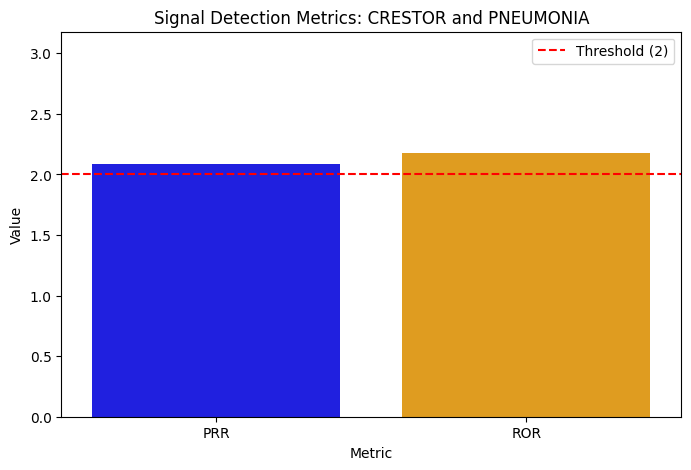

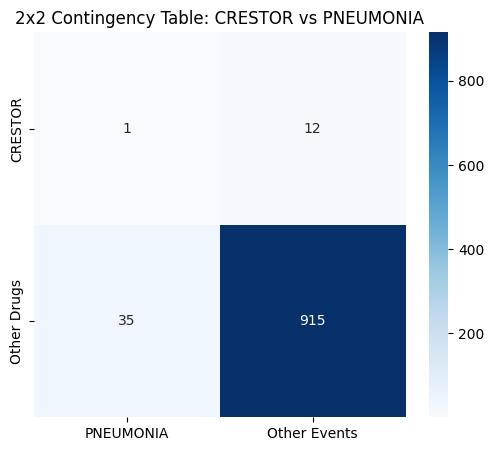

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create a bar chart for PRR and ROR
results = pd.DataFrame({
    'Metric': ['PRR', 'ROR'],
    'Value': [PRR, ROR]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Value', data=results, palette=['blue', 'orange'])
plt.axhline(y=2, color='red', linestyle='--', label='Threshold (2)')
plt.title(f'Signal Detection Metrics: {drug_name} and {event_term}')
plt.ylabel('Value')
plt.ylim(0, max(PRR, ROR) + 1)
plt.legend()
plt.show()

# Create a heatmap for the 2x2 table
table = np.array([[a, b], [c, d]])
plt.figure(figsize=(6, 5))
sns.heatmap(table, annot=True, fmt='d', cmap='Blues',
            xticklabels=[event_term, 'Other Events'],
            yticklabels=[drug_name, 'Other Drugs'])
plt.title(f'2x2 Contingency Table: {drug_name} vs {event_term}')
plt.show()